# **Instacart Analysis**

Team 12 : Aashrith Kandhada, Nilay Jaini, Siddhant Nayar

# **Problem Statement**

In today's competitive business environment and online
retail space, grasping consumer buying behavior is vital for successful marketing
approaches, inventory oversight, and customized product suggestions. This
dataset, abundant with details about customer transactions, products, departments,
and aisle classifications, offers an excellent opportunity to discover valuable
insights into purchasing patterns. This research will utilize unsupervised machine
learning methods to reveal hidden shopping behaviors, identify unique customer
groups, find commonly co-purchased items, and analyze buying trends across
different categories. These findings can assist businesses in optimizing product
placement, enhancing cross-selling techniques, personalizing customer
recommendations, and streamlining supply chain efficiency to better fulfill
consumer needs.

#**Motivation**

In today's competitive online retail world, gaining a deep understanding of consumer purchase behavior is the secret to developing competitive marketing strategies, streamlining inventory management, and crafting personalized shopping experiences. The Instacart dataset offers a new opportunity to mine large-scale transactional data for uncovering latent trends in customer purchase behavior. Through techniques such as market basket analysis and association rule mining, organizations can uncover product bundles, optimize product placement, and personalize cross‐selling efforts. The project is motivated by the need to transform raw transactional data into revenue-increasing and customer satisfaction-improving actionable intelligence.

#**Introduction**

The Instacart Market Basket Analysis project utilizes a complete set of millions of orders, products, and user interactions collected from Instacart's online grocery shopping website. The general objective is to explore and analyze shopping patterns applying unsupervised machine learning methods. Specifically, the project focuses on:

Frequent Itemset Mining: Utilizing algorithms like Apriori for finding frequent product sets.

Association Rule Mining: Mining rules that describe the strength of the association between items in order to enable effective cross-selling and product recommendation strategies.
Customer Segmentation: Analyzing ordering habits and product selection to split customers into distinct segments. With the use of this multivariate approach, the project aims to provide knowledge that will allow businesses to optimize product positioning, enhance promotional activities, and better serve their customers by anticipating their demands.

#**Data Dictionary**

The dataset utilized in this analysis originates from the Instacart Market Basket Analysis competition on Kaggle and contains detailed information on customer transactions. Below is a comprehensive data dictionary for the key variables:

**order_id:**
A unique identifier for each transaction, representing an individual order placed by a customer.

**product_id:**
A unique identifier for each product available in the Instacart catalog.

**add_to_cart_order:**
Indicates the order in which a product was added to the shopping cart during a particular order, providing insight into item selection and purchase priority.

**reordered:**
A binary flag (0 or 1) denoting whether the product has been previously ordered by the customer.

**product_name:**
The descriptive name of the product, which is useful for identifying and categorizing items in the analysis.

**aisle_id:**
A numerical identifier for the aisle where the product is located, facilitating categorization and segmentation by store layout.

**department_id:**
A numerical identifier representing the broader department to which the product belongs, allowing for high-level product grouping.

**aisle:**
The name of the aisle corresponding to the product, providing context for product placement within the store.

**user_id:**
A unique identifier for each customer, enabling the analysis of individual shopping behaviors and patterns.

**eval_set:**
Specifies the subset of data to which the order belongs (e.g., 'prior', 'train', or 'test'), which is important for model training and evaluation.

**order_number:**
Represents the sequential order count for a given customer, indicating the frequency of orders over time.

**order_dow:**
The day of the week when the order was placed (with numerical encoding, such as 0 for Sunday), offering insights into weekly shopping trends.

**order_hour_of_day:**
The hour of the day (using a 24-hour clock) when the order was placed, helping to identify peak shopping times.

**days_since_prior_order:**
The number of days elapsed since the customer’s previous order, which provides a measure of purchase frequency and can indicate seasonal or habitual buying behavior.

This detailed dictionary clarifies the role of each variable, ensuring that every aspect of the dataset is well-understood as you progress with the analysis.

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('/content/drive/MyDrive/subset_data.csv')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,3109255,34099,16,0,Crushed Red Chili Pepper,104,13,spices seasonings,135284,prior,9,0,19,8.0
1,301098,41950,5,0,Organic Tomato Cluster,83,4,fresh vegetables,7293,prior,2,4,15,1.0
2,1181866,45066,8,0,Honeycrisp Apple,24,4,fresh fruits,111385,prior,2,1,17,8.0
3,1678630,8859,2,1,Natural Spring Water,115,7,water seltzer sparkling water,147365,prior,7,0,14,26.0
4,644090,24781,2,0,"PODS Laundry Detergent, Ocean Mist Designed fo...",75,17,laundry,99290,prior,7,0,19,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699995,791266,16283,3,1,Fresh Asparagus,83,4,fresh vegetables,38320,prior,5,2,17,13.0
1699996,938181,30908,31,1,Teriyaki Turkey Jerky,23,19,popcorn jerky,57546,prior,20,0,23,6.0
1699997,3156425,17950,9,1,Vegetable & Pepper Jack Cheese Flatbread Break...,52,1,frozen breakfast,17748,prior,19,0,13,7.0
1699998,3349875,16882,6,1,Baby Spring Mix,123,4,packaged vegetables fruits,37445,prior,3,2,7,18.0


In [5]:
data.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0
product_name,0
aisle_id,0
department_id,0
aisle,0
user_id,0
eval_set,0


In [6]:
data.shape

(1700000, 14)

#**Exploratory Data Analysis (EDA)**

The preliminary exploratory data analysis (M1) offered a fundamental insight into customer buying behaviors, the popularity of products, trends in order timing, and patterns of reordering. The dataset was meticulously cleaned, which involved addressing missing values, eliminating duplicates, and maintaining categorical uniformity across various variables. Key observations were made concerning customer segmentation, product demand, and purchasing cycles. Furthermore, significant features like reorder rates, commonly bought product combinations, and shopping behaviors by day and hour were identified to support future predictive modeling and business insights.

For M2, additional refinements and enhancements were made to elevate the quality and usability of the dataset. These updates comprised:

- **Refinements in Customer Segmentation:**
The categorization of shoppers into low, medium, and high frequency was adjusted based on a more comprehensive statistical analysis of order frequency.  
New clustering methods were explored to enhance the grouping of users according to their shopping habits.

- **Adjustments in Product Popularity:**
A weighted scoring system was introduced to evaluate product demand more precisely by factoring in order frequency, repeat purchases, and the diversity of customers buying each product.  
The evaluation of the most popular aisles and departments was reexamined to reflect trends over time instead of relying exclusively on total order volume.

- **Optimized Analysis of Time-Based Purchases:**
Shopping behaviors segmented by day of the week and hour of the day were analyzed with greater detail, which facilitated the identification of peak shopping times and seasonal variations.  
Hourly purchase behaviors were studied to uncover micro-level trends in shopping activity.

- **Enhancements in Association Rule Mining & Reorder Analysis:**
The process of identifying frequently purchased product pairs was refined through the application of stricter confidence and lift thresholds in association rule mining.  
The calculations of reorder rates were improved to differentiate between regular purchases and occasional repurchases, enhancing the forecasting of repeat orders.

- **Advanced Data Cleaning and Feature Engineering:**
Anomalies in order timestamps were identified and rectified to ensure that time-based analyses remained precise.  
Inconsistencies in product categorization were reviewed and amended, guaranteeing alignment between product designations, aisles, and departments.  
Dimensionality reduction approaches, such as Principal Component Analysis (PCA), were utilized to improve feature selection and enhance the effectiveness of clustering in subsequent phases.


In [7]:
print("Unique users - " + str(data.user_id.nunique()) + ","+ "Unique orders - " +str(data.order_id.nunique()))

Unique users - 186047,Unique orders - 1215049


Out of 1.7 M records - we have ~186k unique customers.

In [8]:
avg_num_orders = data.groupby('user_id')['order_id'].nunique().mean()
print("Average number of orders per user is : ",avg_num_orders)

Average number of orders per user is :  6.530871231463017


In [9]:
orders_per_user = data.groupby('user_id')['order_id'].nunique().reset_index()
orders_per_user = orders_per_user.rename(columns = {'order_id' : 'number of orders'})
orders_per_user.sort_values(by='number of orders', ascending=False)

,user_id,number of orders
164567,182401,80
168462,186704,76
181575,201268,74
126739,140440,74
124219,137629,74
...,...,...
105656,116993,1
105662,116999,1
105664,117001,1
105678,117016,1


In [60]:
orders_per_user['segments'] = pd.cut(
    orders_per_user['number of orders'],
    bins=[0, 8, 18, float('inf')],
    labels=['Low', 'Medium', 'High'],
    right=False
)


In [11]:
orders_per_user.segments.value_counts()

,count
segments,
Low,135687
Medium,35325
High,15035


In [12]:
orders_count = data[['product_id','product_name']].value_counts().reset_index()
orders_count

,product_id,product_name,count
0,24852,Banana,24783
1,13176,Bag of Organic Bananas,19893
2,21137,Organic Strawberries,13805
3,21903,Organic Baby Spinach,12721
4,47209,Organic Hass Avocado,11032
...,...,...,...
39214,41696,Yellow Potatoes,1
39215,31058,"Steamfresh Fresh Frozen Vegetables Broccoli, C...",1
39216,5756,"Cloves, Whole, 100% Organic",1
39217,13810,Reclosable Gallon Freezer Bags,1


In [61]:
data.groupby('order_dow')['order_id'].count().reset_index()\
.rename(columns = {
    'order_id' : 'total_orders'
})

,order_dow,total_orders
0,0,325249
1,1,297483
2,2,221044
3,3,202211
4,4,197900
5,5,220640
6,6,235473


In [14]:
data.groupby('order_hour_of_day')['order_id'].count().reset_index()\
.rename(columns={
    'order_id' : 'total_orders'
})

,order_hour_of_day,total_orders
0,0,11480
1,1,6176
2,2,3685
3,3,2640
4,4,2774
5,5,4709
6,6,15406
7,7,46518
8,8,89619
9,9,128749


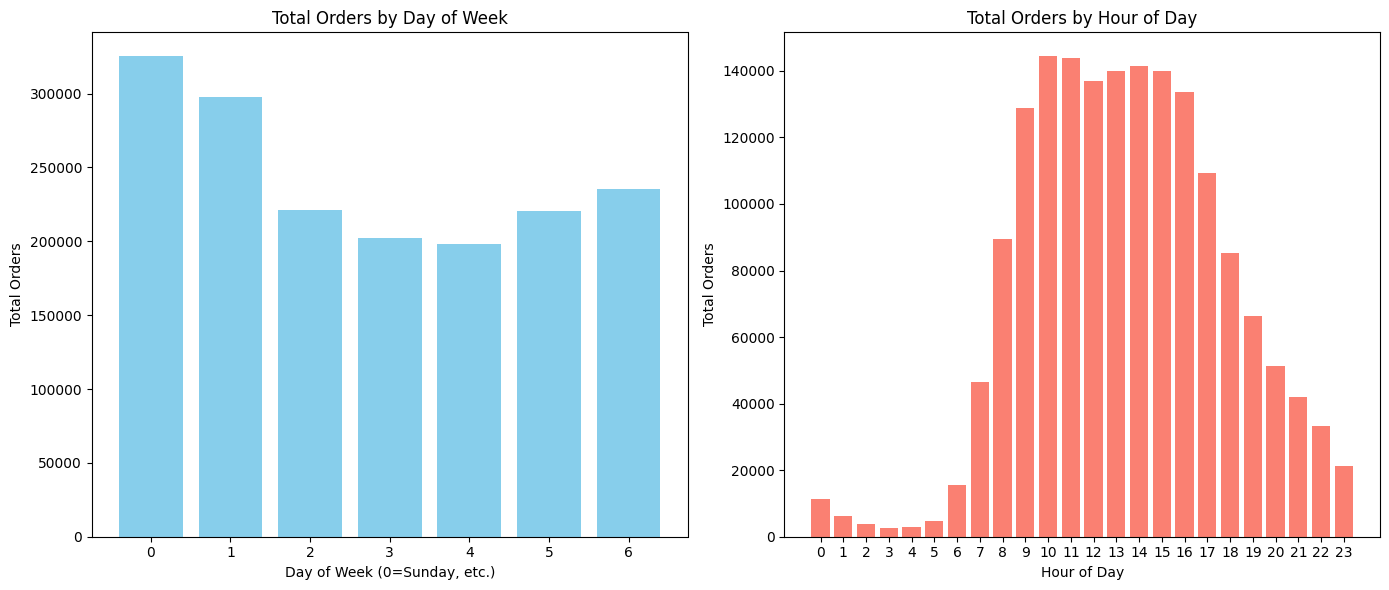

In [62]:
import matplotlib.pyplot as plt

orders_by_dow = data.groupby('order_dow')['order_id'].count().reset_index().rename(columns={'order_id': 'total_orders'})
orders_by_hour = data.groupby('order_hour_of_day')['order_id'].count().reset_index().rename(columns={'order_id': 'total_orders'})

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].bar(orders_by_dow['order_dow'], orders_by_dow['total_orders'], color='skyblue')
axs[0].set_title("Total Orders by Day of Week")
axs[0].set_xlabel("Day of Week (0=Sunday, etc.)")
axs[0].set_ylabel("Total Orders")
axs[0].set_xticks(orders_by_dow['order_dow'])

axs[1].bar(orders_by_hour['order_hour_of_day'], orders_by_hour['total_orders'], color='salmon')
axs[1].set_title("Total Orders by Hour of Day")
axs[1].set_xlabel("Hour of Day")
axs[1].set_ylabel("Total Orders")
axs[1].set_xticks(orders_by_hour['order_hour_of_day'])

plt.tight_layout()
plt.show()


In [16]:
from itertools import combinations
def generate_item_pairs(df):
    item_pairs = []
    for order_id, group in data.groupby('order_id'):
        products = group['product_id'].tolist()
        pairs = list(combinations(sorted(products), 2))
        item_pairs.extend(pairs)
    pairs_df = pd.DataFrame(item_pairs, columns=['product_id', 'product_id_2'])
    return pairs_df

In [17]:
item_pairs_df = generate_item_pairs(data)
item_pairs_df

,product_id,product_id_2
0,23233,31040
1,23233,36550
2,31040,36550
3,1463,17594
4,14540,29742
...,...,...
657357,24852,47626
657358,32030,47626
657359,18523,39993
657360,22350,29270


In [18]:
data

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,3109255,34099,16,0,Crushed Red Chili Pepper,104,13,spices seasonings,135284,prior,9,0,19,8.0
1,301098,41950,5,0,Organic Tomato Cluster,83,4,fresh vegetables,7293,prior,2,4,15,1.0
2,1181866,45066,8,0,Honeycrisp Apple,24,4,fresh fruits,111385,prior,2,1,17,8.0
3,1678630,8859,2,1,Natural Spring Water,115,7,water seltzer sparkling water,147365,prior,7,0,14,26.0
4,644090,24781,2,0,"PODS Laundry Detergent, Ocean Mist Designed fo...",75,17,laundry,99290,prior,7,0,19,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699995,791266,16283,3,1,Fresh Asparagus,83,4,fresh vegetables,38320,prior,5,2,17,13.0
1699996,938181,30908,31,1,Teriyaki Turkey Jerky,23,19,popcorn jerky,57546,prior,20,0,23,6.0
1699997,3156425,17950,9,1,Vegetable & Pepper Jack Cheese Flatbread Break...,52,1,frozen breakfast,17748,prior,19,0,13,7.0
1699998,3349875,16882,6,1,Baby Spring Mix,123,4,packaged vegetables fruits,37445,prior,3,2,7,18.0


In [63]:
prod_map = data[['product_id', 'product_name']].drop_duplicates().set_index('product_id')['product_name']

item_pairs_df['product_name'] = item_pairs_df['product_id'].map(prod_map)
item_pairs_df['product_name_2'] = item_pairs_df['product_id_2'].map(prod_map)

display(item_pairs_df.head())


,product_id,product_id_2,product_name,product_name_2
0,23233,31040,California Sourdough Bread,Sea Salt Pita Chips
1,23233,36550,California Sourdough Bread,Organic Extra Large Grade AA Brown Eggs
2,31040,36550,Sea Salt Pita Chips,Organic Extra Large Grade AA Brown Eggs
3,1463,17594,Organic Milk,Mango Coconut Chia Squeeze
4,14540,29742,Organic Beefsteak Tomato,Organic Toaster Pastries Frosted Lotta Chocolo...


In [64]:
pair_counts = (
    item_pairs_df
    .groupby(['product_id', 'product_name', 'product_id_2', 'product_name_2'])
    .size()
    .reset_index(name='pair_count')
)

top_pairs = pair_counts.sort_values('pair_count', ascending=False).head(40)
display(top_pairs)


,product_id,product_name,product_id_2,product_name_2,pair_count
230080,13176,Bag of Organic Bananas,21137,Organic Strawberries,178
232471,13176,Bag of Organic Bananas,47209,Organic Hass Avocado,176
341137,21137,Organic Strawberries,24852,Banana,157
230156,13176,Bag of Organic Bananas,21903,Organic Baby Spinach,143
391766,24852,Banana,47766,Organic Avocado,143
353186,21903,Organic Baby Spinach,24852,Banana,137
391751,24852,Banana,47626,Large Lemon,134
230705,13176,Bag of Organic Bananas,27966,Organic Raspberries,122
282023,16797,Strawberries,24852,Banana,121
340938,21137,Organic Strawberries,21903,Organic Baby Spinach,107


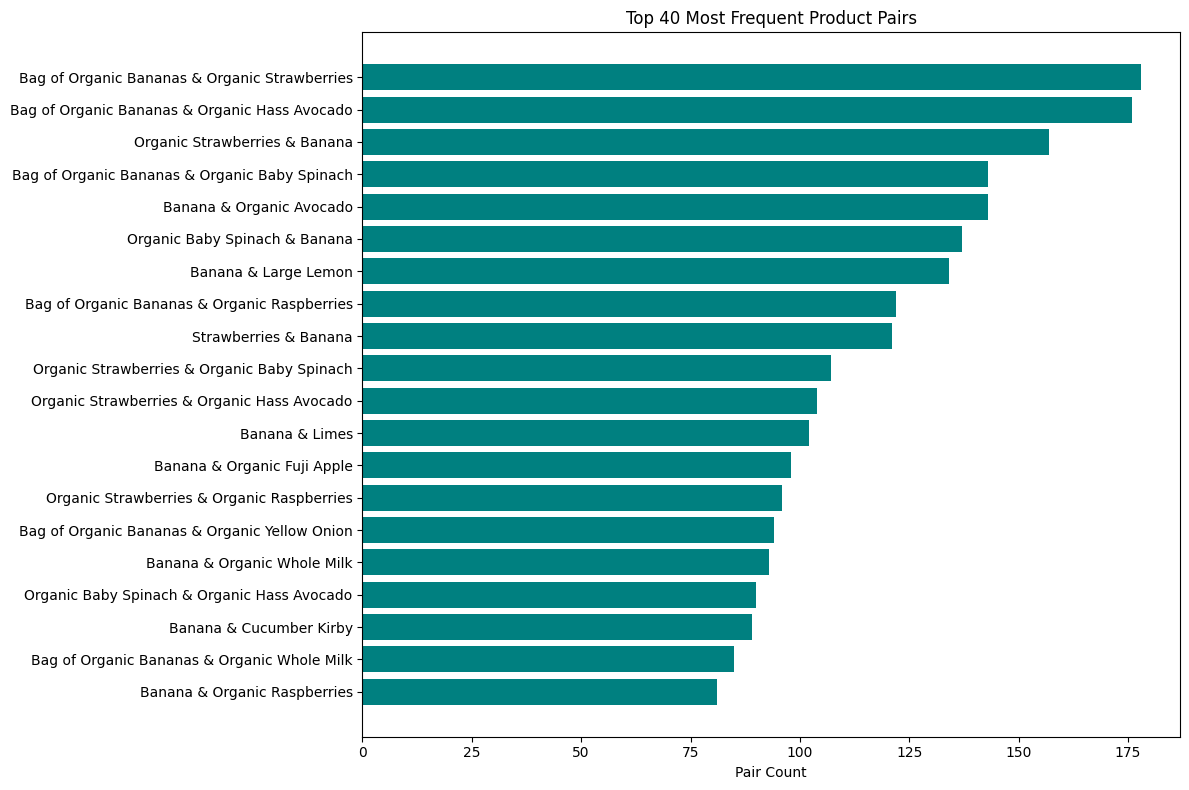

In [65]:
import matplotlib.pyplot as plt

top_pairs = pair_counts.sort_values('pair_count', ascending=False).head(20)
top_pairs['pair_label'] = top_pairs['product_name'] + " & " + top_pairs['product_name_2']

plt.figure(figsize=(12, 8))
plt.barh(top_pairs['pair_label'], top_pairs['pair_count'], color='teal')
plt.xlabel("Pair Count")
plt.title("Top 40 Most Frequent Product Pairs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [66]:
first_card = data[data['add_to_cart_order']==1]
first_card

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
19,1398417,22802,1,0,Mineral Water,115,7,water seltzer sparkling water,101200,prior,6,3,15,30.0
24,627333,6873,1,0,Organic Iceberg Lettuce,83,4,fresh vegetables,104701,prior,19,3,22,8.0
32,693424,23452,1,1,100% Carrot Juice,31,7,refrigerated,34179,prior,49,1,12,7.0
38,1720496,27845,1,1,Organic Whole Milk,84,16,milk,138324,prior,3,6,19,8.0
68,2737770,19863,1,0,Classic Potato Chips,107,19,chips pretzels,4262,prior,3,4,14,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699950,516473,21137,1,0,Organic Strawberries,24,4,fresh fruits,76608,prior,1,0,13,NaN
1699987,2115688,8843,1,0,Milk Chocolate Covered Raisins,45,19,candy chocolate,134733,prior,2,3,13,5.0
1699991,1049207,29871,1,1,Organic Roast Beef,96,20,lunch meat,201498,prior,15,2,20,1.0
1699994,2824,11520,1,1,Large Alfresco Eggs,86,16,eggs,6060,prior,24,5,9,13.0


In [23]:
first_card[['product_id','product_name']].value_counts().reset_index().head(5)

,product_id,product_name,count
0,24852,Banana,5919
1,13176,Bag of Organic Bananas,4158
2,27845,Organic Whole Milk,1638
3,21137,Organic Strawberries,1427
4,47209,Organic Hass Avocado,1205


In [24]:
reordered_products_len = len(data['reordered'][data['reordered'] == 1])
print("number of reorderd products is : ",reordered_products_len)
total_products = len(data['reordered'])
print("number of total products is : ",total_products)
print("percentage of reorderd products is : ",(reordered_products_len/total_products)*100,"%")
print("percentage of first time orderd products is : ",100-(reordered_products_len/total_products)*100,"%")

number of reorderd products is :  1002133
number of total products is :  1700000
percentage of reorderd products is :  58.949 %
percentage of first time orderd products is :  41.051 %


In [26]:
top_dept = data.department_id.value_counts().head(30)

In [27]:
top_dept

,count
department_id,
4,496944
16,284167
19,151121
7,141523
1,116706
13,98349
3,61528
15,55850
20,55223


In [28]:
top_aisle = data.aisle.value_counts().head(30)

In [29]:
top_aisle

,count
aisle,
fresh fruits,190472
fresh vegetables,179242
packaged vegetables fruits,92817
yogurt,76277
packaged cheese,51710
milk,46449
water seltzer sparkling water,44447
chips pretzels,37872
soy lactosefree,33422


we see that dept 496944 is the most common one - lets now break it down by aisle

In [30]:
data[data.department_id==4]

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
1,301098,41950,5,0,Organic Tomato Cluster,83,4,fresh vegetables,7293,prior,2,4,15,1.0
2,1181866,45066,8,0,Honeycrisp Apple,24,4,fresh fruits,111385,prior,2,1,17,8.0
6,737337,13176,7,1,Bag of Organic Bananas,24,4,fresh fruits,173296,prior,5,1,13,8.0
16,2672875,4605,4,1,Yellow Onions,83,4,fresh vegetables,133196,prior,37,4,19,1.0
23,2262426,16797,4,1,Strawberries,24,4,fresh fruits,132352,prior,32,1,10,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699992,3008868,22935,14,1,Organic Yellow Onion,83,4,fresh vegetables,174719,prior,12,0,9,13.0
1699993,633202,13176,6,1,Bag of Organic Bananas,24,4,fresh fruits,110495,prior,7,6,13,30.0
1699995,791266,16283,3,1,Fresh Asparagus,83,4,fresh vegetables,38320,prior,5,2,17,13.0
1699998,3349875,16882,6,1,Baby Spring Mix,123,4,packaged vegetables fruits,37445,prior,3,2,7,18.0


In [31]:
dept_4 = data[data.department_id==4]

In [67]:
aisle_orders = (
    dept_4
    .groupby('aisle')['order_id']
    .count()
    .reset_index(name='total_orders')
)

aisle_orders = aisle_orders.sort_values('total_orders', ascending=False)
aisle_orders.head(20)

,aisle,total_orders
0,fresh fruits,190472
2,fresh vegetables,179242
4,packaged vegetables fruits,92817
1,fresh herbs,19896
3,packaged produce,14517


In [68]:
aisle_unique_products = (
    dept_4
    .groupby('aisle')['product_id']
    .nunique()
    .reset_index(name='distinct_products')
)
aisle_unique_products.head()


,aisle,distinct_products
0,fresh fruits,342
1,fresh herbs,78
2,fresh vegetables,512
3,packaged produce,31
4,packaged vegetables fruits,545


In [69]:
aisle_reorder_rate = (
    dept_4
    .groupby('aisle')['reordered']
    .mean()
    .reset_index(name='reorder_rate')
)
aisle_reorder_rate.head()


,aisle,reorder_rate
0,fresh fruits,0.717791
1,fresh herbs,0.513621
2,fresh vegetables,0.595240
3,packaged produce,0.684026
4,packaged vegetables fruits,0.639495


In [70]:
aisle_analysis = (
    aisle_orders
    .merge(aisle_unique_products, on='aisle', how='left')
    .merge(aisle_reorder_rate, on='aisle', how='left')
)

aisle_analysis = aisle_analysis.sort_values('total_orders', ascending=False)
aisle_analysis.head(10)


,aisle,total_orders,distinct_products,reorder_rate
0,fresh fruits,190472,342,0.717791
1,fresh vegetables,179242,512,0.595240
2,packaged vegetables fruits,92817,545,0.639495
3,fresh herbs,19896,78,0.513621
4,packaged produce,14517,31,0.684026


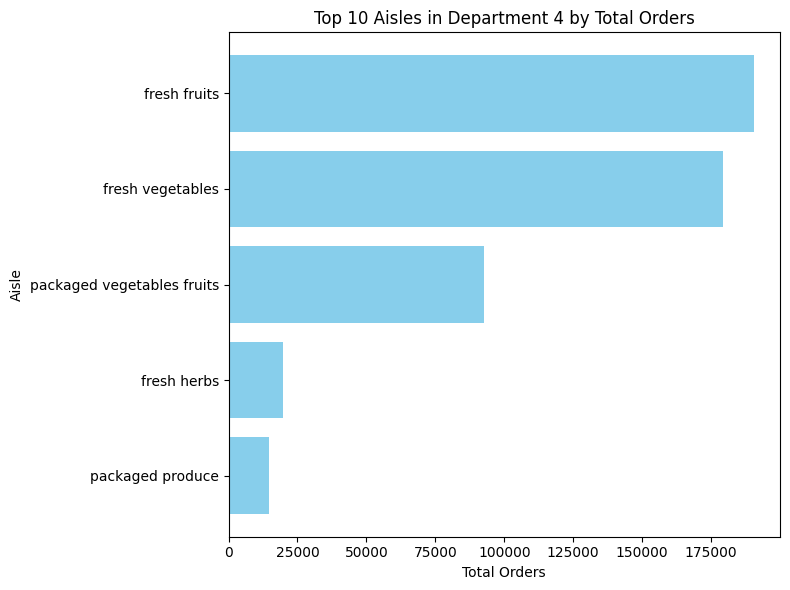

In [71]:
top_aisles = aisle_analysis.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_aisles['aisle'], top_aisles['total_orders'], color='skyblue')
plt.xlabel('Total Orders')
plt.ylabel('Aisle')
plt.title(f'Top 10 Aisles in Department 4 by Total Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


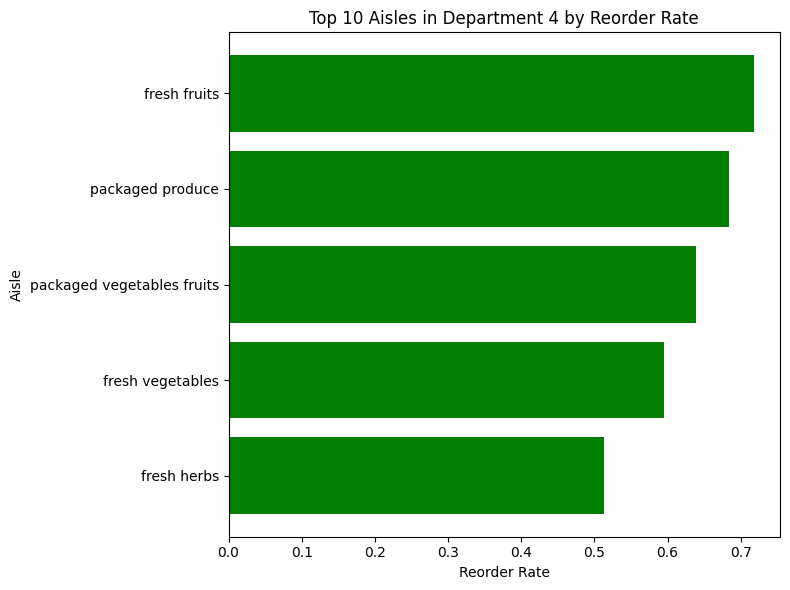

In [37]:
top_aisles_by_reorder = aisle_analysis.sort_values('reorder_rate', ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_aisles_by_reorder['aisle'], top_aisles_by_reorder['reorder_rate'], color='green')
plt.xlabel('Reorder Rate')
plt.ylabel('Aisle')
plt.title(f'Top 10 Aisles in Department 4 by Reorder Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Methodologies

## Clustering and PCA

In [38]:
import pandas as pd

user_features = (
    data
    .groupby('user_id')
    .agg(
        total_orders=('order_number', 'max'),
        total_items=('order_id', 'count'),
        distinct_items=('product_id', 'nunique'),
        reorder_rate=('reordered', 'mean'),
        avg_days_between_orders=('days_since_prior_order', 'mean')
    )
    .reset_index()
)

user_features['avg_days_between_orders'].fillna(0, inplace=True)

user_features.head()


<ipython-input-38-78f02f172968>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_features['avg_days_between_orders'].fillna(0, inplace=True)


,user_id,total_orders,total_items,distinct_items,reorder_rate,avg_days_between_orders
0,1,5,1,1,0.000000,28.000000
1,2,14,7,7,0.571429,11.833333
2,3,5,3,2,0.666667,16.000000
3,5,2,1,1,0.000000,11.000000
4,6,2,2,2,0.000000,6.000000


In [72]:
from sklearn.preprocessing import StandardScaler

X = user_features.drop('user_id', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [40]:
type(X_scaled)

numpy.ndarray

In [73]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
user_features['cluster'] = kmeans.fit_predict(X_scaled)

user_features.head()


,user_id,total_orders,total_items,distinct_items,reorder_rate,avg_days_between_orders,cluster
0,1,5,1,1,0.000000,28.000000,4
1,2,14,7,7,0.571429,11.833333,1
2,3,5,3,2,0.666667,16.000000,1
3,5,2,1,1,0.000000,11.000000,0
4,6,2,2,2,0.000000,6.000000,0


In [42]:
cluster_summary = user_features.groupby('cluster').mean()
display(cluster_summary)


,user_id,total_orders,total_items,distinct_items,reorder_rate,avg_days_between_orders
cluster,,,,,,
0,103113.285955,5.155543,3.103789,3.074380,0.060237,15.155977
1,103040.183902,34.232770,20.313223,17.317621,0.645168,9.677384
2,102989.070404,7.508178,5.052671,4.781312,0.556151,24.129410
3,103112.854027,13.255717,6.434046,5.884585,0.627322,10.455344
4,102487.666232,64.400570,47.291647,36.184623,0.745618,6.124215


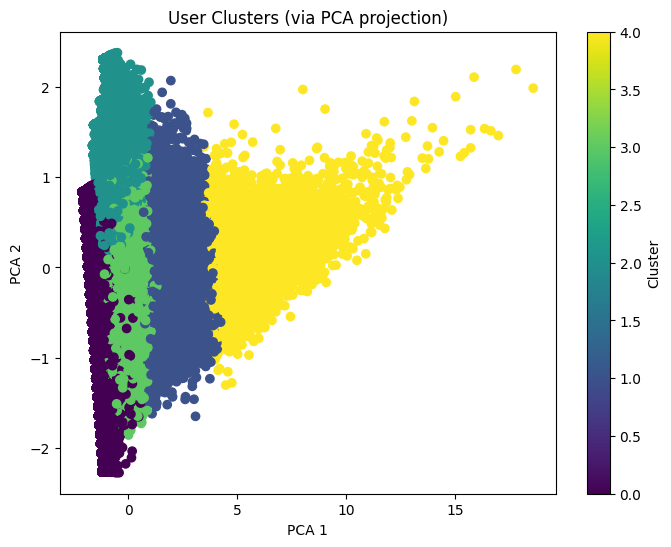

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=user_features['cluster'], cmap='viridis')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('User Clusters (via PCA projection)')
plt.colorbar(label='Cluster')
plt.show()


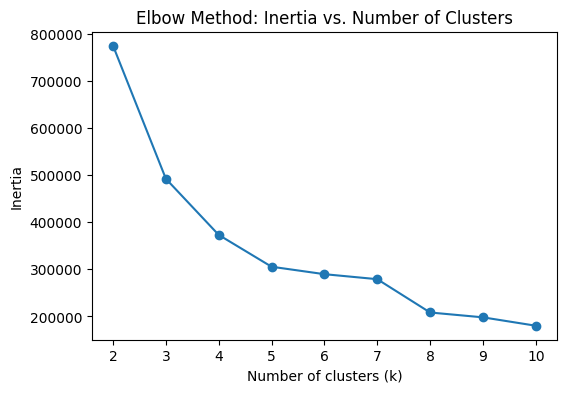

In [74]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia_list = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia_list, marker='o')
plt.title('Elbow Method: Inertia vs. Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [45]:
data

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,3109255,34099,16,0,Crushed Red Chili Pepper,104,13,spices seasonings,135284,prior,9,0,19,8.0
1,301098,41950,5,0,Organic Tomato Cluster,83,4,fresh vegetables,7293,prior,2,4,15,1.0
2,1181866,45066,8,0,Honeycrisp Apple,24,4,fresh fruits,111385,prior,2,1,17,8.0
3,1678630,8859,2,1,Natural Spring Water,115,7,water seltzer sparkling water,147365,prior,7,0,14,26.0
4,644090,24781,2,0,"PODS Laundry Detergent, Ocean Mist Designed fo...",75,17,laundry,99290,prior,7,0,19,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699995,791266,16283,3,1,Fresh Asparagus,83,4,fresh vegetables,38320,prior,5,2,17,13.0
1699996,938181,30908,31,1,Teriyaki Turkey Jerky,23,19,popcorn jerky,57546,prior,20,0,23,6.0
1699997,3156425,17950,9,1,Vegetable & Pepper Jack Cheese Flatbread Break...,52,1,frozen breakfast,17748,prior,19,0,13,7.0
1699998,3349875,16882,6,1,Baby Spring Mix,123,4,packaged vegetables fruits,37445,prior,3,2,7,18.0


## Topic Modeling - LDA

In [47]:
product_names = data['product_name'].tolist()


In [48]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [50]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

cleaned_product_names = []
for product in product_names:
    product_lower = product.lower()
    product_no_punc = re.sub(f"[{string.punctuation}]", " ", product_lower)
    tokens = word_tokenize(product_no_punc)
    filtered_tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    cleaned_product_names.append(filtered_tokens)


In [75]:
from sklearn.feature_extraction.text import CountVectorizer

docs = [" ".join(tokens) for tokens in cleaned_product_names]

vectorizer = CountVectorizer(min_df=5, max_df=0.8)
X = vectorizer.fit_transform(docs)


In [52]:
from sklearn.decomposition import LatentDirichletAllocation

num_topics = 10  # You can tune this value
lda = LatentDirichletAllocation(n_components=num_topics,
                                random_state=42)
lda.fit(X)


LatentDirichletAllocation(random_state=42)

In [53]:
feature_names = vectorizer.get_feature_names_out()
num_top_words = 10

for idx, topic in enumerate(lda.components_):
    print(f"Topic #{idx}:")
    top_word_indices = topic.argsort()[-num_top_words:]
    top_words = [feature_names[i] for i in top_word_indices]
    print(" ".join(top_words))
    print()


Topic #0:
salted apples free carrots reduced apple butter fat milk organic

Topic #1:
cheese cereal tortilla organic fresh potato half chips gluten free

Topic #2:
grain hass brown wheat eggs large avocado bread whole organic

Topic #3:
food orange garlic chicken cheddar juice spinach cheese baby organic

Topic #4:
unsweetened seedless tomatoes pepper green milk tomato red almond organic

Topic #5:
fat plain milk lowfat total strawberry greek banana organic yogurt

Topic #6:
red pasta bar fruit tea onion yellow sauce strawberries organic

Topic #7:
snack baked low extra beans oil coconut crackers lemon organic

Topic #8:
bars roasted natural dark bananas bag sparkling organic chocolate water

Topic #9:
shredded hummus classic ginger cheese organic ice chicken original cream



1. The topic modeling analysis reveals distinct product groupings dominated by fresh produce, dairy, and health-focused items.  
2. Notably, the word “organic” appears in nearly all topics, underscoring strong consumer interest in organic products.  
3. Several clusters point toward health-conscious or specialty diets, mentioning gluten-free, low-fat, and sugar-free items.  
4. Keywords like “snack,” “baked,” and “coconut” imply a growing demand for healthier or alternative snack options.  
5. Items such as “apple,” “banana,” “avocado,” and “orange” appear alongside references to “cheese,” “milk,” and “yogurt,” suggesting frequent pairing of fresh produce with dairy.  
6. The presence of “beans,” “wheat,” and “grain” indicates a robust market for pantry staples and whole-food ingredients.  
7. Terms like “reduced,” “fat,” and “free” reflect ongoing trends around weight management and dietary restrictions.  
8. Clusters mentioning “tea,” “juice,” or “seedless” highlight consumer preferences for beverages and convenience foods.  
9. Associations between “tomatoes,” “onion,” and “pepper” suggest popularity of staple cooking ingredients.  
10. Overall, these topics provide valuable insights for inventory optimization, targeted promotions, and category management.

In [54]:
data

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,3109255,34099,16,0,Crushed Red Chili Pepper,104,13,spices seasonings,135284,prior,9,0,19,8.0
1,301098,41950,5,0,Organic Tomato Cluster,83,4,fresh vegetables,7293,prior,2,4,15,1.0
2,1181866,45066,8,0,Honeycrisp Apple,24,4,fresh fruits,111385,prior,2,1,17,8.0
3,1678630,8859,2,1,Natural Spring Water,115,7,water seltzer sparkling water,147365,prior,7,0,14,26.0
4,644090,24781,2,0,"PODS Laundry Detergent, Ocean Mist Designed fo...",75,17,laundry,99290,prior,7,0,19,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699995,791266,16283,3,1,Fresh Asparagus,83,4,fresh vegetables,38320,prior,5,2,17,13.0
1699996,938181,30908,31,1,Teriyaki Turkey Jerky,23,19,popcorn jerky,57546,prior,20,0,23,6.0
1699997,3156425,17950,9,1,Vegetable & Pepper Jack Cheese Flatbread Break...,52,1,frozen breakfast,17748,prior,19,0,13,7.0
1699998,3349875,16882,6,1,Baby Spring Mix,123,4,packaged vegetables fruits,37445,prior,3,2,7,18.0


In [76]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.decomposition import PCA
import plotly.express as px

departments_to_keep = [19]

filtered_data = data[data['department_id'].isin(departments_to_keep)]

order_aisle = filtered_data[['order_id', 'aisle']].drop_duplicates()

orders = order_aisle.groupby('order_id')['aisle'].unique()

unique_aisles = sorted(order_aisle['aisle'].unique())

aisle_to_index = {aisle: idx for idx, aisle in enumerate(unique_aisles)}

n = len(unique_aisles)
co_occurrence = np.zeros((n, n), dtype=int)

for order, aisles in orders.items():
    for a, b in combinations(aisles, 2):
        i, j = aisle_to_index[a], aisle_to_index[b]
        co_occurrence[i, j] += 1
        co_occurrence[j, i] += 1

np.fill_diagonal(co_occurrence, 1)

pca = PCA(n_components=2, random_state=42)
aisle_pca = pca.fit_transform(co_occurrence)

pca_df = pd.DataFrame(aisle_pca, columns=['PC1', 'PC2'])
pca_df['aisle'] = unique_aisles

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    hover_name='aisle',
    text='aisle',
    title='Aisle Co-occurrence PCA (Filtered by Department)'
)
fig.update_traces(textposition='top center')
fig.show()

**Conclusion:**

From this PCA visualization, we see that **fresh fruits** and **fresh vegetables** stand out as outliers on the right side of the plot, while aisles like **milk**, **packaged cheese**, **yogurt**, and **packaged vegetables fruits** cluster closer together on the left. This suggests that:

1. **Fresh Produce Aisles Are Purchased Differently**  
   Their distance from the main cluster indicates they may have a distinct co-occurrence pattern—perhaps purchased more frequently on their own or with fewer overlapping aisles.

2. **Clustered Aisles Show Strong Co-Occurrence**  
   Aisles in the central cluster (e.g., milk, packaged cheese, yogurt) likely appear together in many orders, implying they share similar purchase behavior or are commonly cross-purchased.

3. **Potential for Store Layout and Cross-Promotions**  
   The close proximity of these middle aisles suggests a natural alignment for in-store placement or online recommendations, while the outliers (fresh fruits/vegetables) might require unique merchandising strategies or promotional bundling.

Overall, this filtered PCA view provides a high-level snapshot of how aisles within these three departments co-occur, offering valuable insights for **inventory management, store layout optimization, and targeted cross-selling** opportunities.

## Market Basket Analysis and Apriori Algorithm

In [ ]:
basket = data.groupby(["user_id","product_id"])["order_id"].count().unstack().notnull()
basket

product_id,1,10,23,25,28,34,37,45,49,54,...,49615,49621,49628,49640,49644,49652,49655,49667,49680,49683
user_id,,,,,,,,,,,,,,,,,,,,,
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206201,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
206202,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
206206,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [58]:
!pip install mlxtend

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(basket,min_support=0.1,use_colnames=True,verbose=1)
frequent_itemsets.sort_values("support", ascending=False)

Processing 580 combinations | Sampling itemset size 5


,support,itemsets
53,0.545893,(24852)
40,0.531834,(21137)
22,0.499851,(13176)
43,0.464862,(21903)
57,0.417449,(26209)
...,...,...
1079,0.100211,"(21137, 45007, 24964, 21903)"
686,0.100211,"(26209, 5876, 21903)"
366,0.100079,"(21616, 40706)"
469,0.100063,"(24852, 39877)"


In [ ]:
num_itemsets = len(frequent_itemsets)
rules = association_rules(frequent_itemsets, num_itemsets, metric="support", min_threshold=0.01)
rules.sort_values(by="lift", ascending=False)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3665,"(13176, 24964)","(47209, 22935)",0.216993,0.209691,0.102673,0.473163,2.256482,1.0,0.057172,1.500103,0.711146,0.316882,0.333379,0.481402
3668,"(47209, 22935)","(13176, 24964)",0.209691,0.216993,0.102673,0.489640,2.256482,1.0,0.057172,1.534225,0.704575,0.316882,0.348205,0.481402
3666,"(13176, 22935)","(47209, 24964)",0.215737,0.211657,0.102673,0.475917,2.248533,1.0,0.057011,1.504234,0.708010,0.316188,0.335210,0.480505
3667,"(47209, 24964)","(13176, 22935)",0.211657,0.215737,0.102673,0.485092,2.248533,1.0,0.057011,1.523113,0.704345,0.316188,0.343450,0.480505
3103,"(46667, 22935)",(24964),0.136275,0.351302,0.104028,0.763365,2.172961,1.0,0.056154,2.741348,0.624966,0.271224,0.635216,0.529743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,(24852),"(13176, 21137)",0.545893,0.322953,0.145477,0.266493,0.825176,1.0,-0.030821,0.923027,-0.318127,0.201110,-0.083392,0.358475
218,(13176),(24852),0.499851,0.545893,0.222031,0.444195,0.813703,1.0,-0.050834,0.817025,-0.314018,0.269549,-0.223952,0.425463
219,(24852),(13176),0.545893,0.499851,0.222031,0.406730,0.813703,1.0,-0.050834,0.843038,-0.335184,0.269549,-0.186186,0.425463
1698,"(13176, 47209)",(24852),0.273492,0.545893,0.116897,0.427424,0.782981,1.0,-0.032400,0.793094,-0.276155,0.166404,-0.260884,0.320781


In [ ]:
def get_product_name(product_id, df):
    try:
        product_name = df.loc[df["product_id"] == product_id, "product_name"].iloc[0]
        return product_name
    except IndexError:
        return None

def arl_recommender(rules_df, id, rec=1):
    sorted_rules = rules_df.sort_values("lift", ascending=False)
    recommendation_list = []
    for i, k in enumerate(sorted_rules["antecedents"]):
        if id in list(k):
            for consequent in list(sorted_rules.iloc[i]["consequents"]):
                if consequent not in recommendation_list:
                    recommendation_list.append(consequent)
    return recommendation_list[:rec]

def names_of_products(rules_df, bought, recommend=5):
    rec = arl_recommender(rules_df, bought, recommend)
    name_of_rec = {}

    bought_name = get_product_name(bought, data['products'])
    if bought_name is None:
        return f"Product ID {bought} not found in the dataset."

    for i in rec:
        recommended_name = get_product_name(i, data['products'])
        name_of_rec[i] = recommended_name if recommended_name else "Unknown Product"

    recommend_df = pd.DataFrame(name_of_rec.items(), columns=["product_id", "product_name"])
    print(f"Bought: {bought_name}\n")
    return recommend_df


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
product_id = int(input("Enter the product ID: "))

if get_product_name(product_id, data['products']):
    recommendations = names_of_products(rules, product_id, 5)
    print(recommendations)
else:
    print(f"Product ID {product_id} not found in the dataset.")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Enter the product ID: 47209
Bought: Organic Hass Avocado

   product_id            product_name
0       13176  Bag of Organic Bananas
1       24964          Organic Garlic
2       22935    Organic Yellow Onion
3       21903    Organic Baby Spinach
4       21137    Organic Strawberries


# Conclusion

In this project, we applied market basket analysis and association rule mining on the Instacart dataset to discover notable patterns in customer purchasing behavior. Our analysis revealed valuable product bundles that offer possibilities for effective cross-selling and inventory management. Through the application of clustering methods and PCA, we also discovered distinct customer segments, indicating variations in shopping behavior that can guide focused marketing efforts.

Despite challenges with high-dimensional data and computational constraints, our iterative process of data cleaning, transformation, and advanced analytics yielded robust and actionable results. These results not only contribute to the understanding of consumer behavior but also provide a sound foundation for the launch of data-driven initiatives in the competitive world of online retailing.

We can include other demographics of customers in the future, explore real-time analytics, and refine our approach further to optimize the shopping experience and operational efficiency.